In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
# matplotlib is the core plotting library in Python
# pyplot is the submodule that gives us chart functions like plt.plot(), plt.show()
import seaborn as sns

# display charts within notebook
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


In [11]:


# parse_dates=['date'] tells pandas to treat the 'date' column as a date, not a string
ft = pd.read_csv('data/foot_traffic.csv', parse_dates=['date'])

# parse earnings_date as a real date
ra = pd.read_csv('data/reported_actuals.csv', parse_dates=['earnings_date'])

# .shape returns (number of rows, number of columns) for each DataFrame
# f-string lets us put variables directly inside a string using {}
print(f'foot_traffic shape:     {ft.shape}')
print(f'reported_actuals shape: {ra.shape}')

foot_traffic shape:     (219200, 4)
reported_actuals shape: (240, 5)


In [13]:
# using .head() to get the first 5 rows
print("Foot Traffic")
ft.head()

Foot Traffic


,ticker,date,state,foot_traffic
0,ACI,2022-02-01,CA,311089
1,ACI,2022-02-01,CO,130695
2,ACI,2022-02-01,ID,248804
3,ACI,2022-02-01,IL,169457
4,ACI,2022-02-01,MD,87143


In [14]:
# .isnull() checks every cell for missing values
# .sum() counts how many nulls are in each column
print("Foot Traffic Nulls")
print(ft.isnull().sum())

print("\nReported Actuals Nulls")
print(ra.isnull().sum())

Foot Traffic Nulls
ticker          0
date            0
state           0
foot_traffic    0
dtype: int64

Reported Actuals Nulls
ticker                 0
quarter                0
reported_sss_pct       0
reported_revenue_mm    0
earnings_date          0
dtype: int64


In [15]:
# .describe() gives us a statistical summary of all numeric columns
# count, mean, min, max, and percentiles (25%, 50%, 75%)
print("Foot Traffic Stats")
print(ft.describe())

print("\nReported Actuals Stats")
print(ra.describe())

Foot Traffic Stats
                      date  foot_traffic
count               219200  2.192000e+05
mean   2023-08-02 12:00:00  2.060013e+05
min    2022-02-01 00:00:00  1.209000e+03
25%    2022-11-01 18:00:00  3.413275e+04
50%    2023-08-02 12:00:00  9.444300e+04
75%    2024-05-02 06:00:00  2.608305e+05
max    2025-01-31 00:00:00  4.037354e+06
std                    NaN  2.784437e+05

Reported Actuals Stats
       reported_sss_pct  reported_revenue_mm        earnings_date
count        240.000000           240.000000                  240
mean           2.191875         21212.050833  2023-10-04 00:24:00
min           -4.760000           704.000000  2022-05-15 00:00:00
25%            0.397500          3281.150000  2023-01-27 00:00:00
50%            2.330000          6564.400000  2023-09-30 12:00:00
75%            3.982500         24047.675000  2024-06-13 12:00:00
max            8.500000        192901.000000  2025-03-01 00:00:00
std            2.768789         35137.334699                

In [16]:
# check that all 20 tickers appear in both datasets
print("Tickers in foot traffic:")
print(sorted(ft['ticker'].unique()))

print("\nTickers in reported actuals:")
print(sorted(ra['ticker'].unique()))

print("\nQuarters covered:")
print(sorted(ra['quarter'].unique()))

Tickers in foot traffic:
['ACI', 'AEO', 'ANF', 'BURL', 'COST', 'DG', 'DLTR', 'FIVE', 'GPS', 'HD', 'JWN', 'KR', 'KSS', 'LOW', 'M', 'ROST', 'TGT', 'TJX', 'ULTA', 'WMT']

Tickers in reported actuals:
['ACI', 'AEO', 'ANF', 'BURL', 'COST', 'DG', 'DLTR', 'FIVE', 'GPS', 'HD', 'JWN', 'KR', 'KSS', 'LOW', 'M', 'ROST', 'TGT', 'TJX', 'ULTA', 'WMT']

Quarters covered:
['2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4']


In [17]:
# confirmed each ticker is tracked across exactly 10 states
print("States per ticker:")
print(ft.groupby('ticker')['state'].nunique())

# validated that every ticker-state combination has an identical number of days
# confirming there are no gaps or missing dates in the dataset
print("\nDays per ticker-state combo:")
print(ft.groupby(['ticker', 'state']).size().describe())

States per ticker:
ticker
ACI     10
AEO     10
ANF     10
BURL    10
COST    10
DG      10
DLTR    10
FIVE    10
GPS     10
HD      10
JWN     10
KR      10
KSS     10
LOW     10
M       10
ROST    10
TGT     10
TJX     10
ULTA    10
WMT     10
Name: state, dtype: int64

Days per ticker-state combo:
count     200.0
mean     1096.0
std         0.0
min      1096.0
25%      1096.0
50%      1096.0
75%      1096.0
max      1096.0
dtype: float64


In [18]:
# compared average foot traffic on weekdays vs weekends
# to identify day-of-week patterns relevant to feature engineering
ft['is_weekend'] = ft['date'].dt.dayofweek >= 5

print("Average foot traffic by day type:")
print(ft.groupby('is_weekend')['foot_traffic'].mean().round(0))

Average foot traffic by day type:
is_weekend
False    185069.0
True     258601.0
Name: foot_traffic, dtype: float64


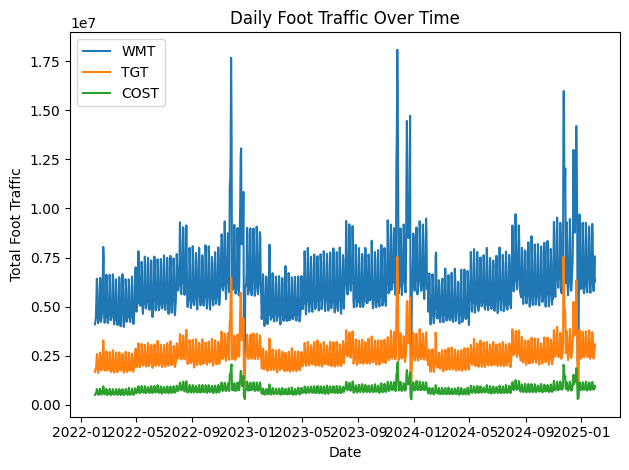

In [19]:
# plotted average daily foot traffic over time for a sample of tickers
# to visually identify seasonality and trends before modeling
sample_tickers = ['WMT', 'TGT', 'COST']

fig, ax = plt.subplots()

for ticker in sample_tickers:
    # filter to one ticker, group by date, sum across all states
    ticker_data = ft[ft['ticker'] == ticker].groupby('date')['foot_traffic'].sum()
    ax.plot(ticker_data.index, ticker_data.values, label=ticker)

ax.set_title('Daily Foot Traffic Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Total Foot Traffic')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# created a function to assign each date to its corresponding fiscal quarter
# Q1=Feb-Apr, Q2=May-Jul, Q3=Aug-Oct, Q4=Nov-Jan
def assign_fiscal_quarter(date):
    month = date.month
    year = date.year
    
    if month in [2, 3, 4]:
        return f'{year}-Q1'
    elif month in [5, 6, 7]:
        return f'{year}-Q2'
    elif month in [8, 9, 10]:
        return f'{year}-Q3'
    else:  # November, December belong to current year Q4, January belongs to prior year Q4
        if month == 1:
            return f'{year - 1}-Q4'
        else:
            return f'{year}-Q4'

# applied the function to every row in the foot traffic dataset
ft['fiscal_quarter'] = ft['date'].apply(assign_fiscal_quarter)

print(ft[['date', 'fiscal_quarter']].head(10))

        date fiscal_quarter
0 2022-02-01        2022-Q1
1 2022-02-01        2022-Q1
2 2022-02-01        2022-Q1
3 2022-02-01        2022-Q1
4 2022-02-01        2022-Q1
5 2022-02-01        2022-Q1
6 2022-02-01        2022-Q1
7 2022-02-01        2022-Q1
8 2022-02-01        2022-Q1
9 2022-02-01        2022-Q1


In [21]:
# confirmed the fiscal quarter assignment covers all 12 expected quarters
print("Unique fiscal quarters in foot traffic:")
print(sorted(ft['fiscal_quarter'].unique()))

Unique fiscal quarters in foot traffic:
['2022-Q1', '2022-Q2', '2022-Q3', '2022-Q4', '2023-Q1', '2023-Q2', '2023-Q3', '2023-Q4', '2024-Q1', '2024-Q2', '2024-Q3', '2024-Q4']


In [23]:
# aggregated daily foot traffic into quarterly metrics per ticker
# total_traffic = sum of all daily visits across all states in that quarter
# avg_daily_traffic = average daily visits, smooths out quarter length differences
# peak_traffic = single highest day in the quarter, captures holiday spikes
quarterly_traffic = ft.groupby(['ticker', 'fiscal_quarter']).agg(
    total_traffic=('foot_traffic', 'sum'),
    avg_daily_traffic=('foot_traffic', 'mean'),
    peak_traffic=('foot_traffic', 'max')
).reset_index()

print(quarterly_traffic.shape)
print(quarterly_traffic.head(10))

(240, 5)
  ticker fiscal_quarter  total_traffic  avg_daily_traffic  peak_traffic
0    ACI        2022-Q1      202268326      227267.782022        487850
1    ACI        2022-Q2      233439648      253738.747826        618092
2    ACI        2022-Q3      249841425      271566.766304        604246
3    ACI        2022-Q4      297254969      323103.227174       1290565
4    ACI        2023-Q1      203940745      229146.904494        541736
5    ACI        2023-Q2      239804278      260656.823913        605120
6    ACI        2023-Q3      250436836      272213.952174        608126
7    ACI        2023-Q4      304904039      331417.433696       1124286
8    ACI        2024-Q1      205154016      227948.906667        527572
9    ACI        2024-Q2      241830589      262859.335870        624630


In [24]:
# calculated quarter-over-quarter traffic growth rate per ticker
# sorted by ticker and quarter to ensure growth is calculated in the right order
quarterly_traffic = quarterly_traffic.sort_values(['ticker', 'fiscal_quarter'])

# pct_change() calculates the percentage change from the previous row
# groupby ensures we don't calculate growth across different tickers
quarterly_traffic['traffic_qoq_growth'] = (
    quarterly_traffic.groupby('ticker')['total_traffic']
    .pct_change() * 100
)

print(quarterly_traffic.head(12))

   ticker fiscal_quarter  total_traffic  avg_daily_traffic  peak_traffic  \
0     ACI        2022-Q1      202268326      227267.782022        487850   
1     ACI        2022-Q2      233439648      253738.747826        618092   
2     ACI        2022-Q3      249841425      271566.766304        604246   
3     ACI        2022-Q4      297254969      323103.227174       1290565   
4     ACI        2023-Q1      203940745      229146.904494        541736   
5     ACI        2023-Q2      239804278      260656.823913        605120   
6     ACI        2023-Q3      250436836      272213.952174        608126   
7     ACI        2023-Q4      304904039      331417.433696       1124286   
8     ACI        2024-Q1      205154016      227948.906667        527572   
9     ACI        2024-Q2      241830589      262859.335870        624630   
10    ACI        2024-Q3      251331804      273186.743478        634264   
11    ACI        2024-Q4      314089023      341401.111957       1153638   

    traffic